In [330]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [331]:
df = pd.read_csv("train.csv")
print("Jumlah missing value:\n",df.isnull().sum()/len(df) * 100)
print("Duplikat data:", df.duplicated().sum())
print("Jumlah baris dan kolom:", df.shape)
df.head()
df.info()

Jumlah missing value:
 Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64
Duplikat data: 0
Jumlah baris dan kolom: (1460, 81)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1

In [332]:
# Menghapus atribut yang isinya hilang lebih dari 50%
missing_persen = df.isnull().sum()/len(df) * 100
kolom_drop = missing_persen[missing_persen > 50].index.tolist()
df.drop(columns=kolom_drop, inplace=True)
df = df.drop(columns=['FireplaceQu'])
df.shape

(1460, 75)

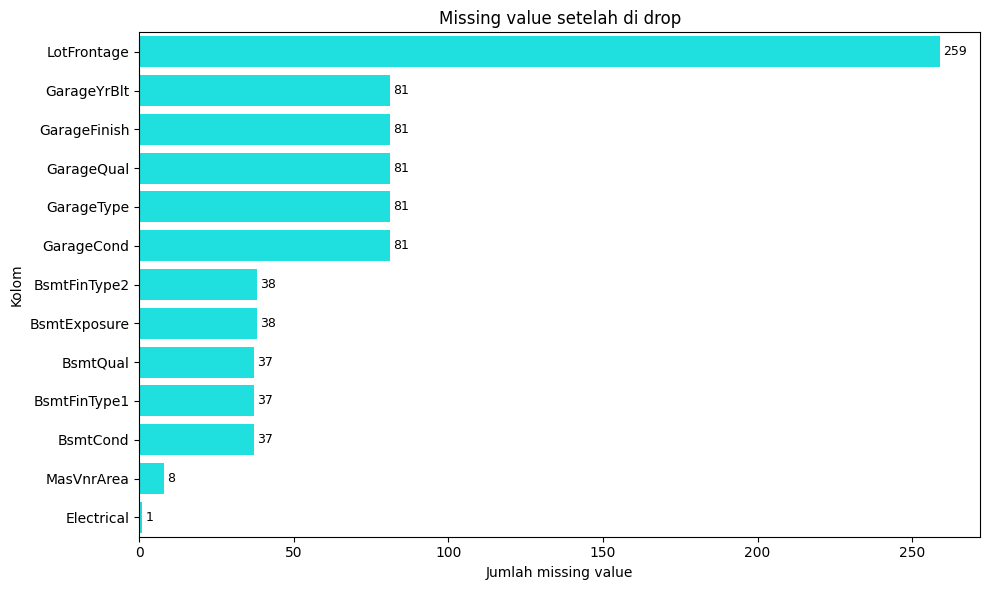

In [333]:
sisa_missing = df.isnull().sum()
sisa_missing = sisa_missing[sisa_missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=sisa_missing.values, y=sisa_missing.index, color='cyan')
plt.xlabel('Jumlah missing value')
plt.ylabel('Kolom')
plt.title("Missing value setelah di drop")

for i, v in enumerate(sisa_missing.values):
    plt.text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [334]:
#Mengubah isi atribut yang memiliki missing value
kolom_teks = df.select_dtypes(include=['object','string']).columns
kolom_angka = df.select_dtypes(include=['number']).columns

df[kolom_teks] = df[kolom_teks].fillna('unknown')
df[kolom_angka] = df[kolom_angka].fillna(0)

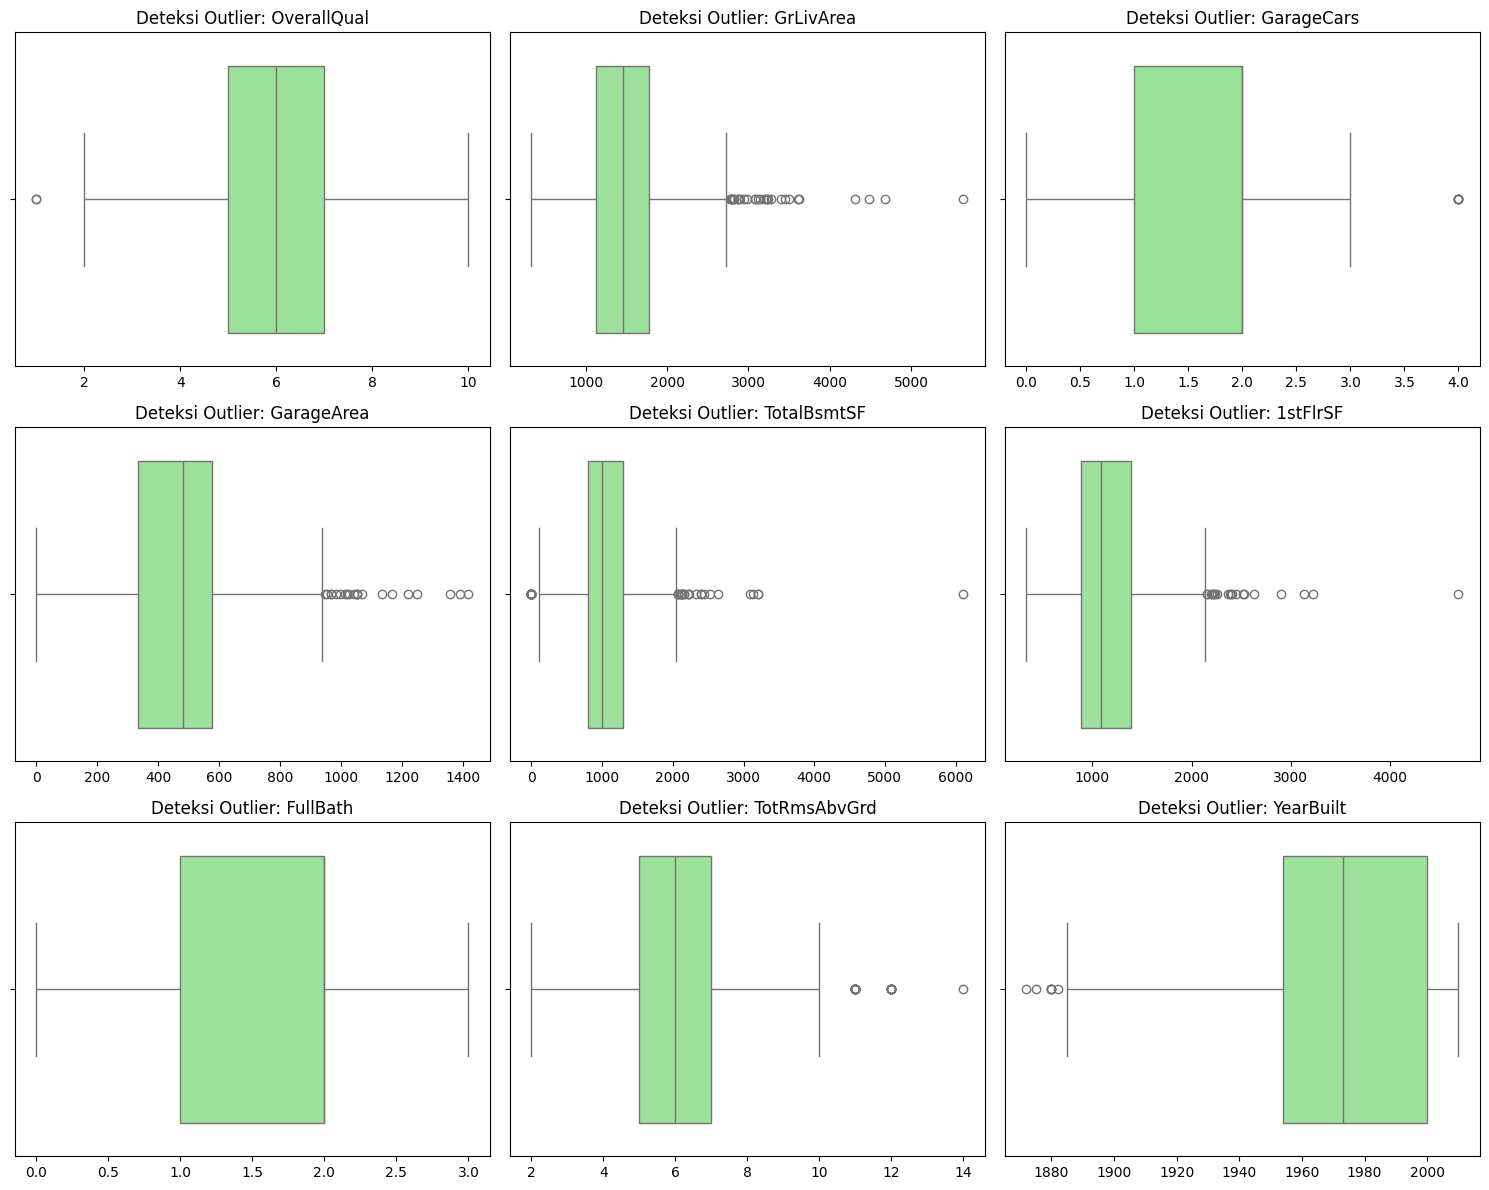

In [335]:
# Korelasi top 9 fitur pada harga rumah
korelasi_target = df[kolom_angka].corr()['SalePrice'].abs().sort_values(ascending=False)
top_9_fitur = korelasi_target.iloc[1:10]

jml_kolom_grafik = 3
jml_baris_grafik = 3

plt.figure(figsize=(15,12))

for i, col in enumerate(top_9_fitur.index, 1):
    plt.subplot(jml_baris_grafik, jml_kolom_grafik, i)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f"Deteksi Outlier: {col}", fontsize = 12)
    plt.xlabel('')

plt.tight_layout()
plt.show()

In [336]:
df_clean = df.copy()
kolom_target = ['TotalBsmtSF', 'GrLivArea']
for col in kolom_target:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

df_clean = df_clean[(df_clean[col] >= batas_bawah) & (df_clean[col] <= batas_atas)]

print(f"Jumlah data sebelum dihapus: {df.shape[0]}")
print(f"Jumlah data setelah outlier dihapus: {df_clean.shape[0]}")
df = df_clean

df.to_csv("train_clean.csv", index=False)
print("Dataset bersih tersimpan:", df.shape)
print(df.head())

print("Penghapusan outlier pada GrLivArea dan TotalBsmtSF dikarenakan outlier yang tinggi sehingga bisa menarik data lainnya seperti rumah biasa saja menjadi memiliki harga yang tinggi. ")

Jumlah data sebelum dihapus: 1460
Jumlah data setelah outlier dihapus: 1429
Dataset bersih tersimpan: (1429, 75)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street LotShape LandContour  \
0   1          60       RL         65.0     8450   Pave      Reg         Lvl   
1   2          20       RL         80.0     9600   Pave      Reg         Lvl   
2   3          60       RL         68.0    11250   Pave      IR1         Lvl   
3   4          70       RL         60.0     9550   Pave      IR1         Lvl   
4   5          60       RL         84.0    14260   Pave      IR1         Lvl   

  Utilities LotConfig  ... EnclosedPorch 3SsnPorch ScreenPorch PoolArea  \
0    AllPub    Inside  ...             0         0           0        0   
1    AllPub       FR2  ...             0         0           0        0   
2    AllPub    Inside  ...             0         0           0        0   
3    AllPub    Corner  ...           272         0           0        0   
4    AllPub       FR2  ...     

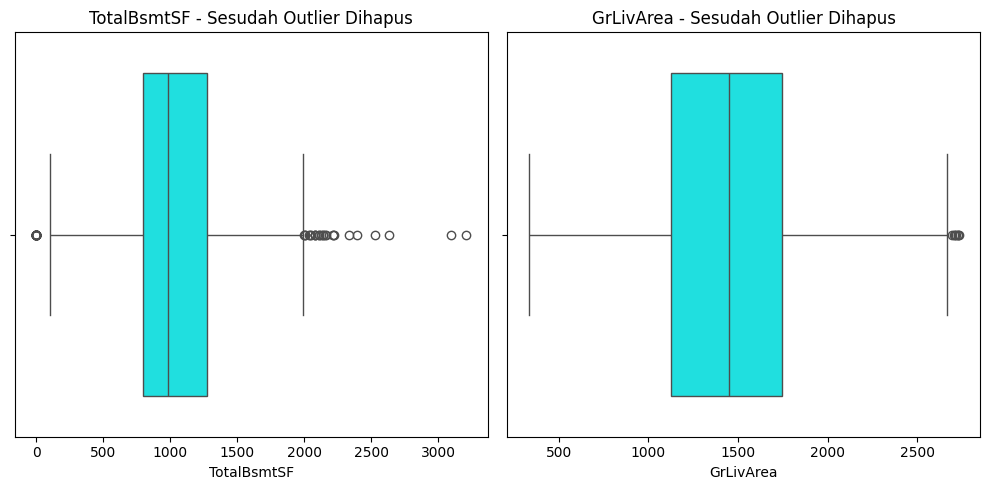

In [337]:
kolom_target = ['TotalBsmtSF', 'GrLivArea']

fig, axes = plt.subplots(1, 2, figsize=(10,5))

for i, col in enumerate(kolom_target):
    sns.boxplot(x=df[col], color='cyan', ax=axes[i])
    axes[i].set_title(f'{col} - Sesudah Outlier Dihapus')

plt.tight_layout()
plt.show()

In [338]:
# Mengamankan ID terlebih dahulu
ID_rumah = df['Id']
df = df.drop(columns=['Id'])

# Setelah ID dihilangkan
kolom_teks = df.select_dtypes(include=['object','category']).columns
kolom_angka = df.select_dtypes(include=['int64','float64']).columns

df_encoded = pd.get_dummies(df, columns=kolom_teks, drop_first=False)
scaler = StandardScaler()
df_encoded[kolom_angka] = scaler.fit_transform(df_encoded[kolom_angka])

df_encoded.insert(0,'Id', ID_rumah)

print(df_encoded.head())

   Id  MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  YearBuilt  \
0   1    0.076225     0.240633 -0.191357     0.701469    -0.517421   1.058189   
1   2   -0.863803     0.688724 -0.074428    -0.040499     2.204276   0.156429   
2   3    0.076225     0.330252  0.093339     0.701469    -0.517421   0.991392   
3   4    0.311232     0.091270 -0.079512     0.701469    -0.517421  -1.880882   
4   5    0.076225     0.808215  0.399387     1.443437    -0.517421   0.957994   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  SaleType_ConLw  SaleType_New  \
0      0.885988    0.579914    0.634065  ...           False         False   
1     -0.416957   -0.576932    1.269046  ...           False         False   
2      0.837731    0.379237    0.120477  ...           False         False   
3     -0.706501   -0.576932   -0.509835  ...           False         False   
4      0.741216    1.488864    0.515006  ...           False         False   

   SaleType_Oth  SaleType_WD  SaleCondition_

C:\Users\M S I\AppData\Local\Temp\ipykernel_25048\503806946.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  kolom_teks = df.select_dtypes(include=['object','category']).columns


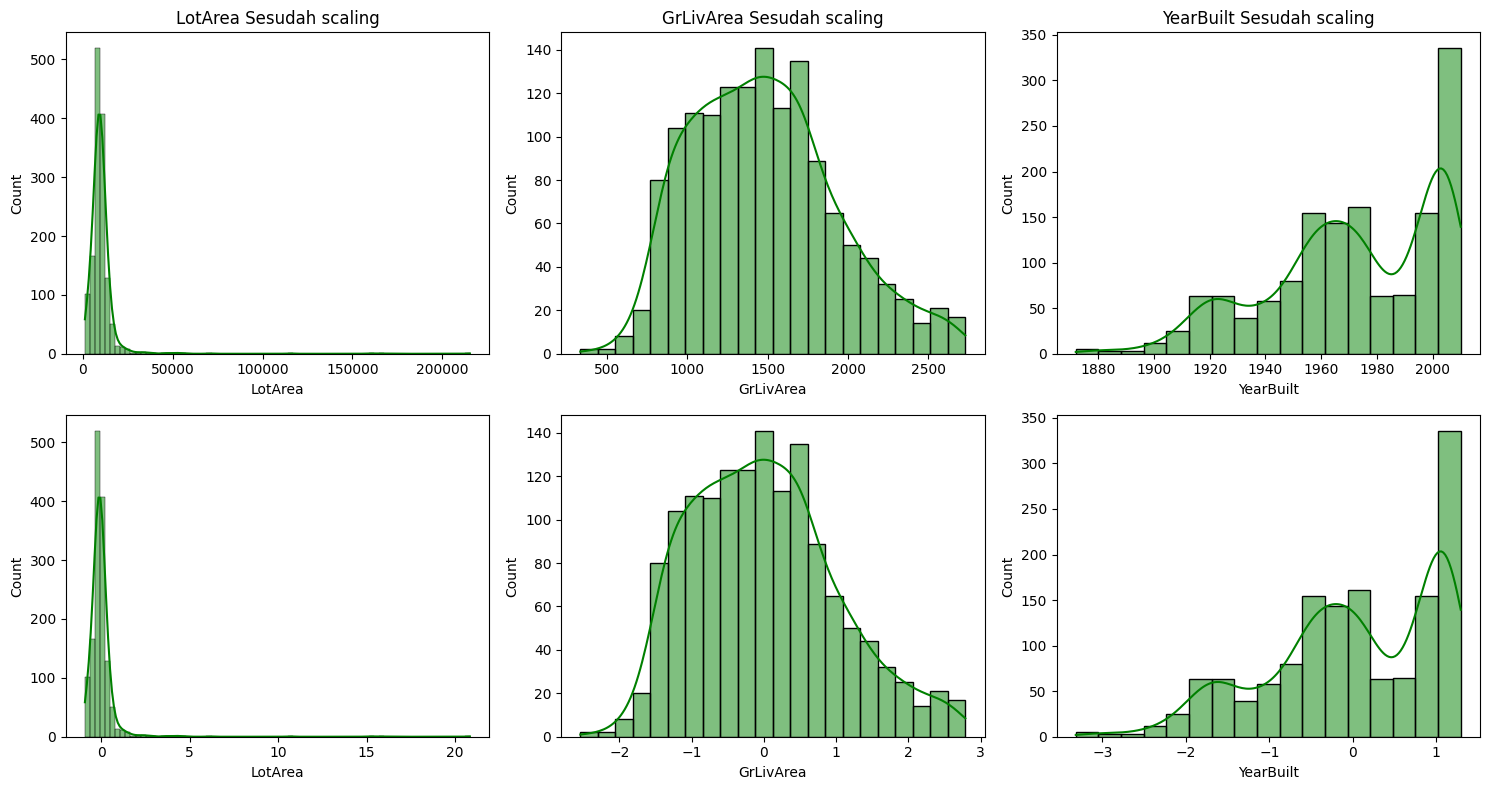

In [ ]:
kolom_tampil = ['LotArea', 'GrLivArea', 'YearBuilt']

fig, axes = plt.subplots(2,3, figsize=(15,8))

for i, col in enumerate(kolom_tampil):
    sns.histplot(df[col], kde=True, color="green", ax=axes[0,i])
    axes[0,i].set_title(f'{col} Sebelum scaling')

    sns.histplot(df_encoded[col], kde=True, color="cyan", ax=axes[1,i])
    axes[1,i].set_title(f'{col} Sesudah scaling')
    
plt.tight_layout()
plt.show()

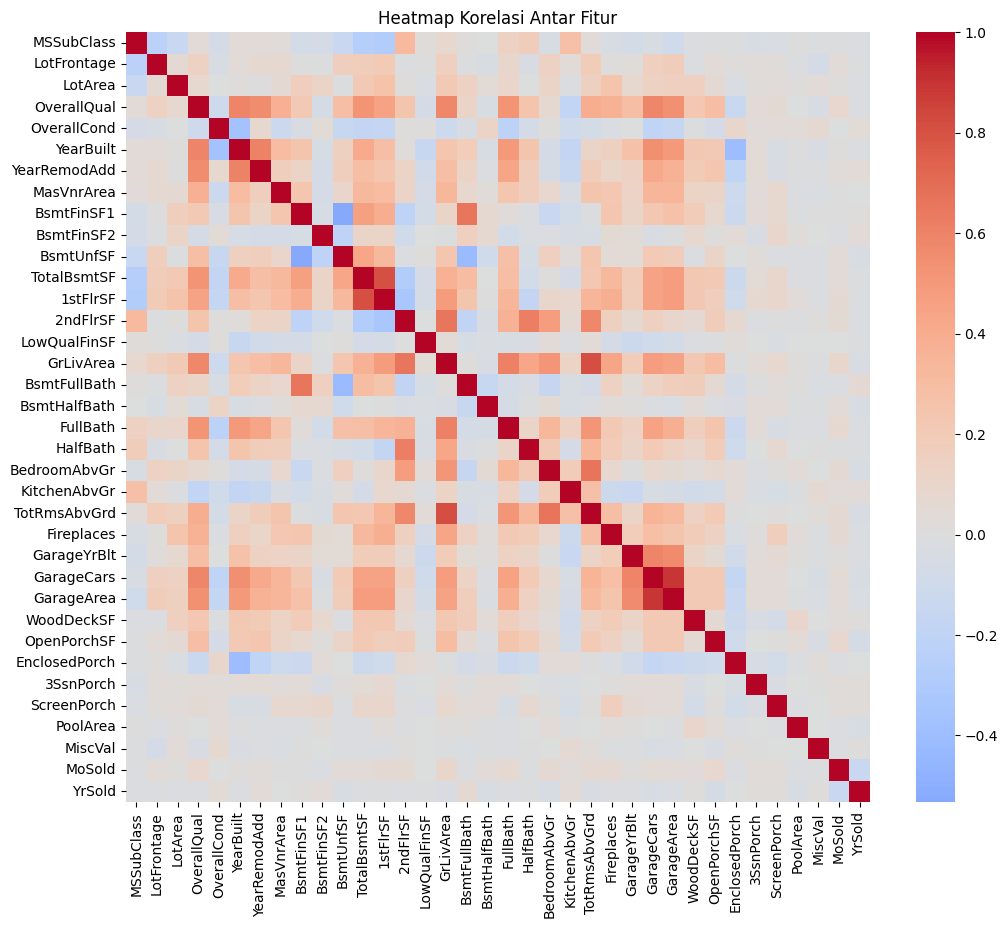

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.drop(columns=['SalePrice']).corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

In [ ]:
# analisis korelasi untuk mengidentifikasi atribut yang sangat berkorelasi
corr_matrix = df.drop(columns=['SalePrice']).corr(numeric_only=True).abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

thershold = 0.80
to_drop = [column for column in upper_tri.columns if any (upper_tri[column] > thershold)]

df = df.drop(columns=to_drop)
print(to_drop)

['1stFlrSF', 'TotRmsAbvGrd', 'GarageArea']


Jumlah fitur awal (setelah OHE): 234 kolom
Jumlah fitur setelah PCA: 129 kolom
Total Varians yang dijelaskan: 89.91%


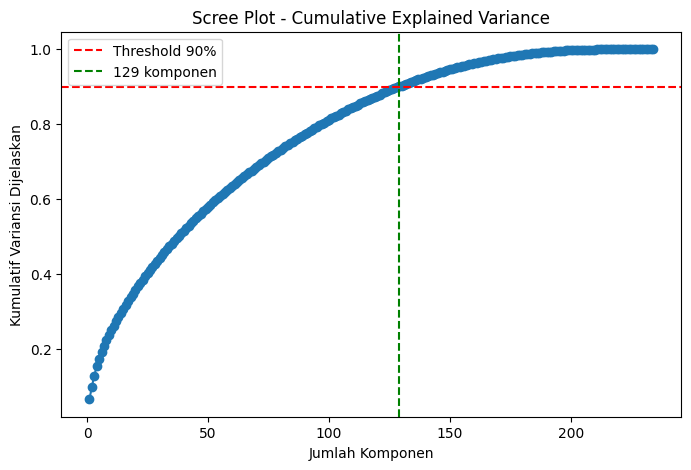

In [ ]:
# Tahap PCA
X = df.drop(columns=['SalePrice', 'Id'], errors='ignore')
Y = df['SalePrice']

X_encoded = pd.get_dummies(X, drop_first=True)

X_scale = scaler.fit_transform(X_encoded)

pca_full = PCA()
pca_full.fit(X_scale)

explained_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_needed = np.argmax(explained_variance >= 0.90) + 1

pca = PCA(n_components = n_components_needed, random_state=42)
X_pca = pca.fit_transform(X_scale)

kolom_pc = [f'PC{i+1}' for i in range(X_pca.shape[1])]

df_Pca = pd.DataFrame(data=X_pca, columns=kolom_pc, index=df.index)

df_final = pd.concat([df_Pca, Y], axis=1 )

print(f"Jumlah fitur awal (setelah OHE): {X_encoded.shape[1]} kolom")
print(f"Jumlah fitur setelah PCA: {df_Pca.shape[1]} kolom")
print(f"Total Varians yang dijelaskan: {sum(pca.explained_variance_ratio_)*100:.2f}%")

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label='Threshold 90%')
plt.axvline(x=n_components_needed, color='g', linestyle='--', label=f'{n_components_needed} komponen')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Kumulatif Variansi Dijelaskan')
plt.title('Scree Plot - Cumulative Explained Variance')
plt.legend()
plt.show()